In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

load dataset

In [4]:
df = pd.read_csv("IAPT_activity _march 2026.csv")

check column

In [5]:
df.columns

Index(['REPORTING_PERIOD_START', 'REPORTING_PERIOD_END', 'GROUP_TYPE',
       'ORG_CODE1', 'ORG_NAME1', 'ORG_CODE2', 'ORG_NAME2', 'MEASURE_ID',
       'MEASURE_NAME', 'MEASURE_VALUE_SUPPRESSED'],
      dtype='object')

In [6]:
# Check unique measure names

df['MEASURE_NAME'].unique()

array(['Count_ReferralsReceived', 'Count_SelfReferrals',
       'Count_GPReferrals', 'Count_HealthVisitorReferrals',
       'Count_OtherPrimaryCareReferrals', 'Count_CarerReferrals',
       'Count_LAReferrals', 'Count_EmployerReferrals',
       'Count_JusticeSystemReferrals', 'Count_ChildHealthReferrals',
       'Count_IndependentVoluntaryReferrals',
       'Count_SecondaryCareReferrals', 'Count_OtherMHReferrals',
       'Count_InternalReferrals', 'Count_OtherReferrals',
       'Count_NHSTalkingTherapiesReferrals',
       'Count_OpenReferralNoActivity60days',
       'Count_OpenReferralNoActivity61to90days',
       'Count_OpenReferralNoActivity91to120days',
       'Count_OpenReferralNoActivityOver120days', 'Count_FirstAssessment',
       'Count_FirstAssessment28days', 'Count_FirstAssessment29to56days',
       'Count_FirstAssessment57to90days',
       'Count_FirstAssessmentOver90days', 'Count_EndedBeforeAssessment',
       'Count_WaitingForAssessment',
       'Count_WaitingForAssessmentO

fliter rtt measures

In [12]:
# Filter RTT-related measures

rtt_df = df[
    df['MEASURE_NAME'].isin([
        'Mean_WaitAssessment',
        'Median_WaitAssessment',
        'Mean_WaitFinishedCourseTreatment',
        'Median_WaitFinishedCourseTreatment'
    ])
]

rtt_df.head(2)

,REPORTING_PERIOD_START,REPORTING_PERIOD_END,GROUP_TYPE,ORG_CODE1,ORG_NAME1,ORG_CODE2,ORG_NAME2,MEASURE_ID,MEASURE_NAME,MEASURE_VALUE_SUPPRESSED
47,2026-03-01,2026-03-31,England,all,all SubICBs,all,all Providers,M050,Mean_WaitFinishedCourseTreatment,24.8
48,2026-03-01,2026-03-31,England,all,all SubICBs,all,all Providers,M051,Median_WaitFinishedCourseTreatment,17.0


shape

In [9]:
rtt_df.shape

(2586, 10)

organization type

In [10]:
rtt_df['GROUP_TYPE'].unique()

array(['England', 'CommissioningRegion', 'Provider', 'SubICB',
       'SubICB/Provider'], dtype=object)

check sample data

In [11]:
rtt_df.head(10)

,REPORTING_PERIOD_START,REPORTING_PERIOD_END,GROUP_TYPE,ORG_CODE1,ORG_NAME1,ORG_CODE2,ORG_NAME2,MEASURE_ID,MEASURE_NAME,MEASURE_VALUE_SUPPRESSED
47,2026-03-01,2026-03-31,England,all,all SubICBs,all,all Providers,M050,Mean_WaitFinishedCourseTreatment,24.8
48,2026-03-01,2026-03-31,England,all,all SubICBs,all,all Providers,M051,Median_WaitFinishedCourseTreatment,17.0
264,2026-03-01,2026-03-31,CommissioningRegion,InvalidRegionCode,Unknown,all,all Providers,M050,Mean_WaitFinishedCourseTreatment,17.4
265,2026-03-01,2026-03-31,CommissioningRegion,InvalidRegionCode,Unknown,all,all Providers,M051,Median_WaitFinishedCourseTreatment,13.0
481,2026-03-01,2026-03-31,CommissioningRegion,Y56,LONDON COMMISSIONING REGION,all,all Providers,M050,Mean_WaitFinishedCourseTreatment,23.2
482,2026-03-01,2026-03-31,CommissioningRegion,Y56,LONDON COMMISSIONING REGION,all,all Providers,M051,Median_WaitFinishedCourseTreatment,15.0
698,2026-03-01,2026-03-31,CommissioningRegion,Y58,SOUTH WEST COMMISSIONING REGION,all,all Providers,M050,Mean_WaitFinishedCourseTreatment,23.0
699,2026-03-01,2026-03-31,CommissioningRegion,Y58,SOUTH WEST COMMISSIONING REGION,all,all Providers,M051,Median_WaitFinishedCourseTreatment,19.0
915,2026-03-01,2026-03-31,CommissioningRegion,Y59,SOUTH EAST COMMISSIONING REGION,all,all Providers,M050,Mean_WaitFinishedCourseTreatment,18.2
916,2026-03-01,2026-03-31,CommissioningRegion,Y59,SOUTH EAST COMMISSIONING REGION,all,all Providers,M051,Median_WaitFinishedCourseTreatment,14.0


remove invalid rows

In [13]:
# Remove invalid regions

rtt_df = rtt_df[
    rtt_df['ORG_NAME1'] != 'Unknown'
]

only regional data

In [14]:
# Keep only regional data

region_df = rtt_df[
    rtt_df['GROUP_TYPE'] == 'CommissioningRegion'
]

region_df.head()

,REPORTING_PERIOD_START,REPORTING_PERIOD_END,GROUP_TYPE,ORG_CODE1,ORG_NAME1,ORG_CODE2,ORG_NAME2,MEASURE_ID,MEASURE_NAME,MEASURE_VALUE_SUPPRESSED
481,2026-03-01,2026-03-31,CommissioningRegion,Y56,LONDON COMMISSIONING REGION,all,all Providers,M050,Mean_WaitFinishedCourseTreatment,23.2
482,2026-03-01,2026-03-31,CommissioningRegion,Y56,LONDON COMMISSIONING REGION,all,all Providers,M051,Median_WaitFinishedCourseTreatment,15.0
698,2026-03-01,2026-03-31,CommissioningRegion,Y58,SOUTH WEST COMMISSIONING REGION,all,all Providers,M050,Mean_WaitFinishedCourseTreatment,23.0
699,2026-03-01,2026-03-31,CommissioningRegion,Y58,SOUTH WEST COMMISSIONING REGION,all,all Providers,M051,Median_WaitFinishedCourseTreatment,19.0
915,2026-03-01,2026-03-31,CommissioningRegion,Y59,SOUTH EAST COMMISSIONING REGION,all,all Providers,M050,Mean_WaitFinishedCourseTreatment,18.2


check unique RTT measures

In [15]:
region_df['MEASURE_NAME'].unique()

array(['Mean_WaitFinishedCourseTreatment',
       'Median_WaitFinishedCourseTreatment'], dtype=object)

separate MEAN RTT

In [16]:
mean_df = region_df[
    region_df['MEASURE_NAME']
    ==
    'Mean_WaitFinishedCourseTreatment'
]

mean_df.head()

,REPORTING_PERIOD_START,REPORTING_PERIOD_END,GROUP_TYPE,ORG_CODE1,ORG_NAME1,ORG_CODE2,ORG_NAME2,MEASURE_ID,MEASURE_NAME,MEASURE_VALUE_SUPPRESSED
481,2026-03-01,2026-03-31,CommissioningRegion,Y56,LONDON COMMISSIONING REGION,all,all Providers,M050,Mean_WaitFinishedCourseTreatment,23.2
698,2026-03-01,2026-03-31,CommissioningRegion,Y58,SOUTH WEST COMMISSIONING REGION,all,all Providers,M050,Mean_WaitFinishedCourseTreatment,23.0
915,2026-03-01,2026-03-31,CommissioningRegion,Y59,SOUTH EAST COMMISSIONING REGION,all,all Providers,M050,Mean_WaitFinishedCourseTreatment,18.2
1132,2026-03-01,2026-03-31,CommissioningRegion,Y60,MIDLANDS COMMISSIONING REGION,all,all Providers,M050,Mean_WaitFinishedCourseTreatment,28.6
1349,2026-03-01,2026-03-31,CommissioningRegion,Y61,EAST OF ENGLAND COMMISSIONING REGION,all,all Providers,M050,Mean_WaitFinishedCourseTreatment,26.7


separate median RTT

In [17]:
median_df = region_df[
    region_df['MEASURE_NAME']
    ==
    'Median_WaitFinishedCourseTreatment'
]

median_df.head()

,REPORTING_PERIOD_START,REPORTING_PERIOD_END,GROUP_TYPE,ORG_CODE1,ORG_NAME1,ORG_CODE2,ORG_NAME2,MEASURE_ID,MEASURE_NAME,MEASURE_VALUE_SUPPRESSED
482,2026-03-01,2026-03-31,CommissioningRegion,Y56,LONDON COMMISSIONING REGION,all,all Providers,M051,Median_WaitFinishedCourseTreatment,15.0
699,2026-03-01,2026-03-31,CommissioningRegion,Y58,SOUTH WEST COMMISSIONING REGION,all,all Providers,M051,Median_WaitFinishedCourseTreatment,19.0
916,2026-03-01,2026-03-31,CommissioningRegion,Y59,SOUTH EAST COMMISSIONING REGION,all,all Providers,M051,Median_WaitFinishedCourseTreatment,14.0
1133,2026-03-01,2026-03-31,CommissioningRegion,Y60,MIDLANDS COMMISSIONING REGION,all,all Providers,M051,Median_WaitFinishedCourseTreatment,19.0
1350,2026-03-01,2026-03-31,CommissioningRegion,Y61,EAST OF ENGLAND COMMISSIONING REGION,all,all Providers,M051,Median_WaitFinishedCourseTreatment,17.0


RTT graph

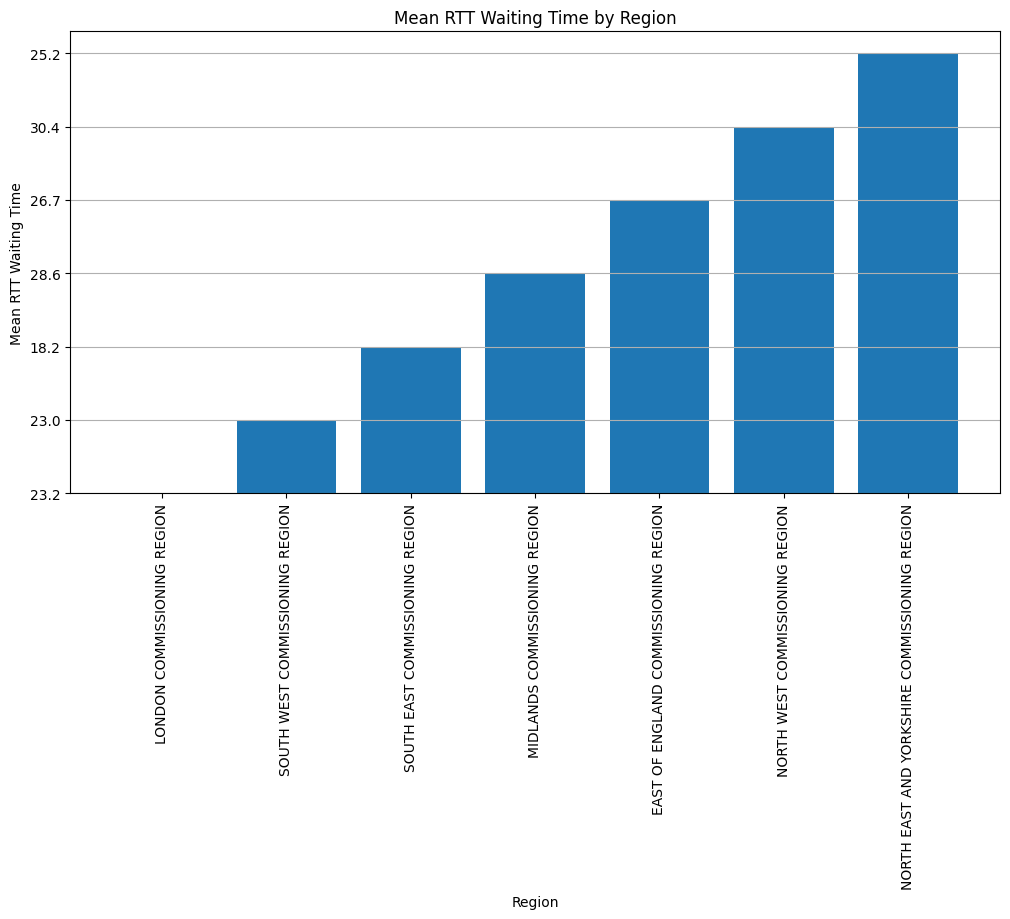

In [18]:
plt.figure(figsize=(12,6))

plt.bar(
    mean_df['ORG_NAME1'],
    mean_df['MEASURE_VALUE_SUPPRESSED']
)

plt.xticks(rotation=90)

plt.xlabel("Region")

plt.ylabel("Mean RTT Waiting Time")

plt.title(
    "Mean RTT Waiting Time by Region"
)

plt.grid(axis='y')

plt.show()

MEDIAN RTT chart

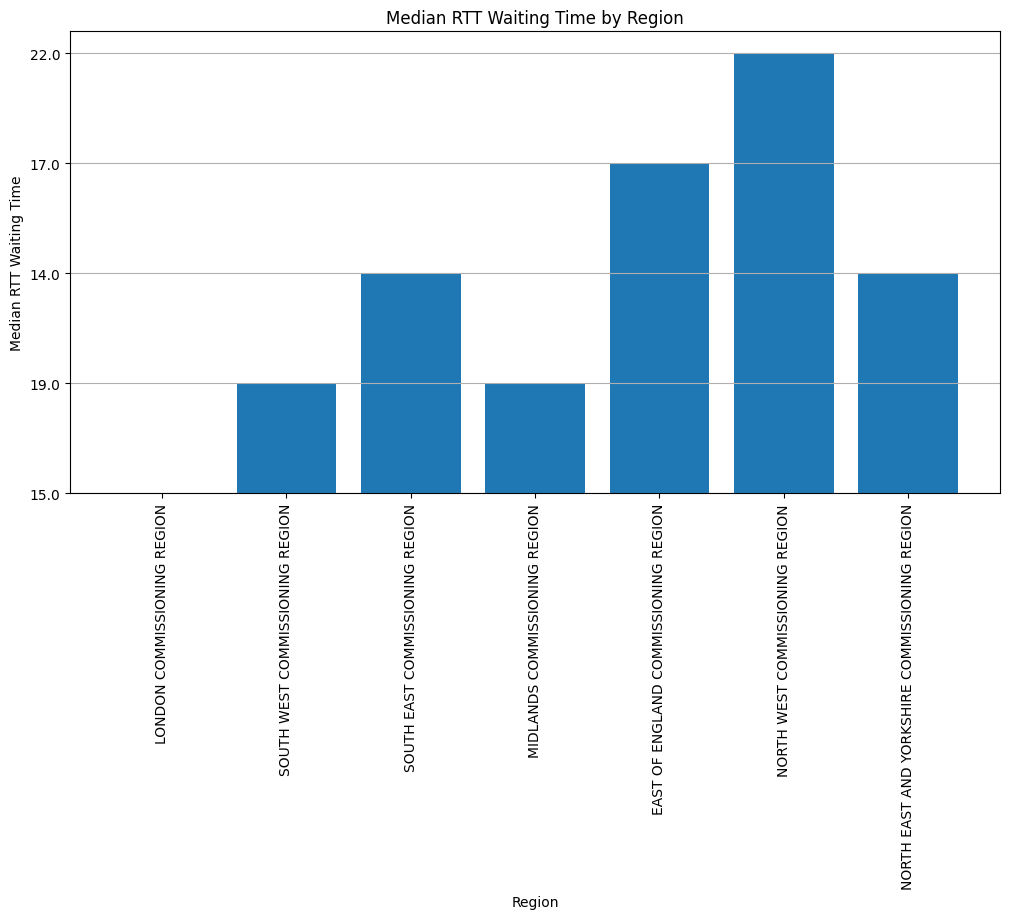

In [19]:
plt.figure(figsize=(12,6))

plt.bar(
    median_df['ORG_NAME1'],
    median_df['MEASURE_VALUE_SUPPRESSED']
)

plt.xticks(rotation=90)

plt.xlabel("Region")

plt.ylabel("Median RTT Waiting Time")

plt.title(
    "Median RTT Waiting Time by Region"
)

plt.grid(axis='y')

plt.show()

RTT comparison table

In [20]:
comparison_df = pd.DataFrame({

    "Region":
    mean_df['ORG_NAME1'].values,

    "Mean_RTT":
    mean_df['MEASURE_VALUE_SUPPRESSED'].values,

    "Median_RTT":
    median_df['MEASURE_VALUE_SUPPRESSED'].values
})

comparison_df

,Region,Mean_RTT,Median_RTT
0,LONDON COMMISSIONING REGION,23.2,15.0
1,SOUTH WEST COMMISSIONING REGION,23.0,19.0
2,SOUTH EAST COMMISSIONING REGION,18.2,14.0
3,MIDLANDS COMMISSIONING REGION,28.6,19.0
4,EAST OF ENGLAND COMMISSIONING REGION,26.7,17.0
5,NORTH WEST COMMISSIONING REGION,30.4,22.0
6,NORTH EAST AND YORKSHIRE COMMISSIONING REGION,25.2,14.0


mean  median comparison graph

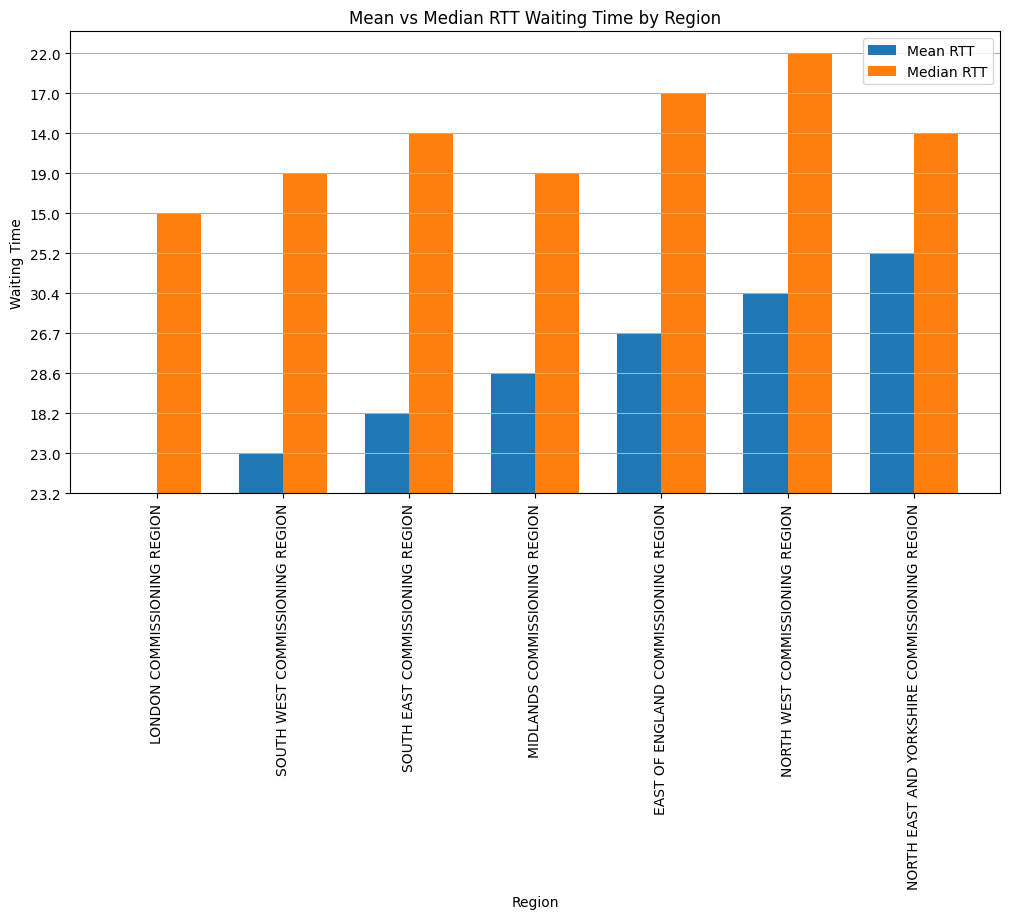

In [37]:
plt.figure(figsize=(12,6))

x = np.arange(len(comparison_df['Region']))
width = 0.35

plt.bar(
    x - width/2,
    comparison_df['Mean_RTT'],
    width,
    label='Mean RTT'
)

plt.bar(
    x + width/2,
    comparison_df['Median_RTT'],
    width,
    label='Median RTT'
)

plt.xticks(
    x,
    comparison_df['Region'],
    rotation=90
)

plt.xlabel("Region")

plt.ylabel("Waiting Time")

plt.title(
    "Mean vs Median RTT Waiting Time by Region"
)

plt.legend()

plt.grid(axis='y')

plt.show()

save csv

In [21]:
comparison_df.to_csv(
    "cleaned_rtt_analysis.csv",
    index=False
)

DISORDER related measures

In [31]:
# Disorder-related measures

disorder_df = df[
    df['MEASURE_NAME'].isin([

        'Count_FirstPHQOnly',
        'Count_FirstGADOnly',
        'Count_PairedPHQAndGAD',
        'Count_NoPHQ',
        'Count_NoGAD',
        'Count_SecondTreatment'

    ])
]

disorder_counts = disorder_df[
    'MEASURE_NAME'
].value_counts()

disorder_counts

,count
MEASURE_NAME,
Count_SecondTreatment,1293
Count_FirstPHQOnly,1293
Count_NoPHQ,1293


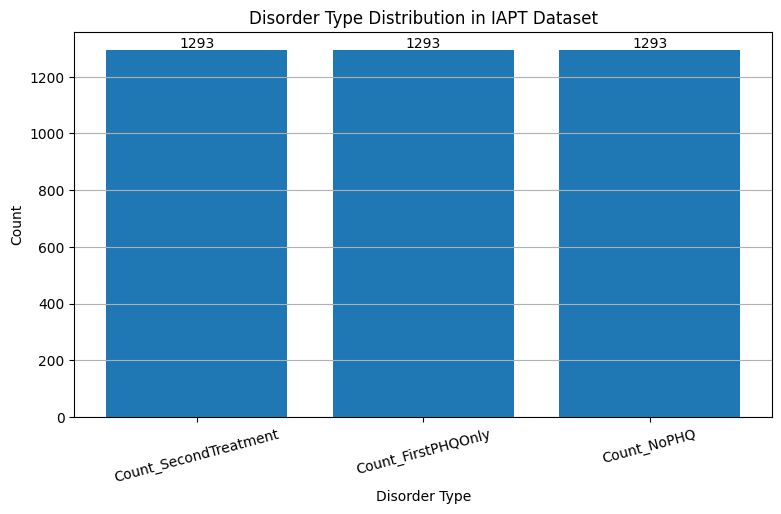

In [33]:
plt.figure(figsize=(9,5))

bars = plt.bar(
    disorder_counts.index,
    disorder_counts.values
)

plt.xticks(rotation=15)

plt.xlabel("Disorder Type")

plt.ylabel("Count")

plt.title(
    "Disorder Type Distribution in IAPT Dataset"
)

# value labels
for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 10,
        int(yval),
        ha='center'
    )

plt.grid(axis='y')

plt.show()

region mean RTT csv

In [34]:
mean_df.to_csv(
    "mean_rtt_by_region.csv",
    index=False
)

median rtt

In [35]:
median_df.to_csv(
    "median_rtt_by_region.csv",
    index=False
)

disorder analysis

In [36]:
disorder_counts.to_csv(
    "disorder_type_distribution.csv"
)